# Cached Methylation deepTools Workflow

Run the cached matrix-building script, then separately plot profile plots from the saved matrices.


## 1. Environment and imports


In [7]:
import os
import shlex
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "repo_paths.py").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate repo root from the current working directory.")
    PROJECT_ROOT = PROJECT_ROOT.parent

matplotlib_cache_dir = Path(tempfile.gettempdir()) / f"matplotlib-{os.getuid()}"
matplotlib_cache_dir.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(matplotlib_cache_dir)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from figures.colors import REPLICATE_COLORS
from figures.utils.figures_utils import REGION_CALLING_TOOL_LABELS, REGION_CALLING_TOOL_ORDER


## 2. User knobs


In [8]:
SCRIPT_PATH = PROJECT_ROOT / "analysis" / "01_region_calling_analysis" / "run_methylation_deeptools.py"
CONFIGS_PATH = PROJECT_ROOT / "analysis" / "01_region_calling_analysis" / "slurm_code" / "configs.txt"
OUT_DIR = PROJECT_ROOT / "analysis" / "01_region_calling_analysis" / "out" / "methylation_deeptools"

RUN_SAMPLES = ["WGBS_colon-primary-tumor_1_meth", "WGBS_colon-primary-tumor_2_meth", "WGBS_colon-primary-tumor_3_meth"]
DISPLAY_SAMPLES = ["WGBS_colon-primary-tumor_1_meth", "WGBS_colon-primary-tumor_2_meth", "WGBS_colon-primary-tumor_3_meth"]
RUN_TOOLS = list(REGION_CALLING_TOOL_ORDER)
DISPLAY_TOOLS = None

RUN_WORKERS = 75
WGBS_COMPUTE_MATRIX_BIN_SIZE = 10_000
ARRAY_COMPUTE_MATRIX_BIN_SIZE = 25_000
REGION_BODY_LENGTH = 500_000
WGBS_FLANK_LENGTH = 400_000
ARRAY_FLANK_LENGTH = 250_000
AVERAGE_TYPE_BINS = "mean"
FORCE_REBUILD_BIGWIGS = False
FORCE_RERUN_MATRICES = False
COMBINE_RUN_SAMPLES_PER_TOOL = True

PLOT_PROFILE_AVERAGE_TYPE = "median"
PLOT_WIDTH = 22
PLOT_HEIGHT = 12
PLOT_DPI = 200
PLOT_YMIN = 0.4
PLOT_YMAX = 0.8
FORCE_RERUN_PLOTS = True

TABLES_DIR = OUT_DIR / "tables"
PLOTS_DIR = OUT_DIR / "plots"
DEEPTOOLS_EXPECTED_ENV_BIN = Path(
    "/uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/env/jt_wgbs_analysis/bin"
)

for directory in [OUT_DIR, TABLES_DIR, PLOTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

display(Markdown(f"Using output root: `{OUT_DIR}`"))


Using output root: `/uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/out/methylation_deeptools`

## 3. Run cached matrix script


In [3]:
def build_run_command() -> list[str]:
    command = [
        sys.executable,
        str(SCRIPT_PATH),
        "--configs-path",
        str(CONFIGS_PATH),
        "--output-dir",
        str(OUT_DIR),
        "--wgbs-compute-matrix-bin-size",
        str(WGBS_COMPUTE_MATRIX_BIN_SIZE),
        "--array-compute-matrix-bin-size",
        str(ARRAY_COMPUTE_MATRIX_BIN_SIZE),
        "--region-body-length",
        str(REGION_BODY_LENGTH),
        "--wgbs-flank-length",
        str(WGBS_FLANK_LENGTH),
        "--array-flank-length",
        str(ARRAY_FLANK_LENGTH),
        "--average-type-bins",
        str(AVERAGE_TYPE_BINS),
    ]
    if RUN_WORKERS is not None:
        command.extend(["--workers", str(RUN_WORKERS)])
    if FORCE_REBUILD_BIGWIGS:
        command.append("--force-rebuild-bigwigs")
    if FORCE_RERUN_MATRICES:
        command.append("--force-rerun-matrices")
    if RUN_SAMPLES is not None:
        command.extend(["--samples", *[str(sample) for sample in RUN_SAMPLES]])
    if COMBINE_RUN_SAMPLES_PER_TOOL and RUN_SAMPLES is not None and len(RUN_SAMPLES) > 1:
        command.append("--combine-samples-per-tool")
    if RUN_TOOLS is not None:
        command.extend(["--tools", *[str(tool) for tool in RUN_TOOLS]])
    return command


run_command = build_run_command()
print("$", shlex.join(run_command))
subprocess.run(run_command, check=True)


$ /uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/env/jt_wgbs_analysis/bin/python /uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/run_methylation_deeptools.py --configs-path /uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/slurm_code/configs.txt --output-dir /uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/out/methylation_deeptools --wgbs-compute-matrix-bin-size 10000 --array-compute-matrix-bin-size 25000 --region-body-length 500000 --wgbs-flank-length 400000 --array-flank-length 250000 --average-type-bins mean --workers 75 --force-rerun-matrices --samples WGBS_colon-primary-tumor_1_meth WGBS_colon-primary-tumor_2_meth WGBS_colon-primary-tumor_3_meth --combine-samples-per-tool --tools methylseg_wgbs methylseg_hm450k methylseekr dnmtools dnmtools_array dnmtools_pmr mmseekr methylasso

CompletedProcess(args=['/uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/env/jt_wgbs_analysis/bin/python', '/uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/run_methylation_deeptools.py', '--configs-path', '/uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/slurm_code/configs.txt', '--output-dir', '/uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/out/methylation_deeptools', '--wgbs-compute-matrix-bin-size', '10000', '--array-compute-matrix-bin-size', '25000', '--region-body-length', '500000', '--wgbs-flank-length', '400000', '--array-flank-length', '250000', '--average-type-bins', 'mean', '--workers', '75', '--force-rerun-matrices', '--samples', 'WGBS_colon-primary-tumor_1_meth', 'WGBS_colon-primary-tumor_2_meth', 'WGBS_colon-primary-tumor_3_meth', '--combine-samples-per-tool', '--tools

## 4. Load cached manifests


In [9]:
def read_tsv_if_exists(path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    return pd.read_csv(path, sep="\t")


signal_manifest_df = read_tsv_if_exists(TABLES_DIR / "signal_manifest.tsv")
region_manifest_df = read_tsv_if_exists(TABLES_DIR / "region_manifest.tsv")
deeptools_region_manifest_df = read_tsv_if_exists(TABLES_DIR / "deeptools_region_manifest.tsv")
matrix_outputs_df = read_tsv_if_exists(TABLES_DIR / "deeptools_matrix_outputs.tsv")
failures_df = read_tsv_if_exists(TABLES_DIR / "failures.tsv")

display(Markdown("### Signal manifest"))
display(signal_manifest_df)
display(Markdown("### Region manifest"))
display(region_manifest_df)
display(Markdown("### deepTools region manifest"))
display(deeptools_region_manifest_df)
display(Markdown("### Matrix outputs manifest"))
display(matrix_outputs_df)
display(Markdown("### Failures"))
display(failures_df)


### Signal manifest

,config_order,sample,sample_id,genome,signal_track,signal_mode,signal_source,bigwig_path,cache_used
0,3,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,hg38,hm450k,probe_level,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,True
1,3,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,hg38,wgbs,cpg_level,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,True
2,4,WGBS_colon-primary-tumor_2_meth,WGBS_colon-primary-tumor_2_meth,hg38,hm450k,probe_level,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,True
3,4,WGBS_colon-primary-tumor_2_meth,WGBS_colon-primary-tumor_2_meth,hg38,wgbs,cpg_level,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,True
4,5,WGBS_colon-primary-tumor_3_meth,WGBS_colon-primary-tumor_3_meth,hg38,hm450k,probe_level,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,True
5,5,WGBS_colon-primary-tumor_3_meth,WGBS_colon-primary-tumor_3_meth,hg38,wgbs,cpg_level,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,True


### Region manifest

,config_order,tool_order,sample,sample_id,sample_label,member_samples,member_sample_ids,n_samples,matrix_mode,tool,...,signal_sources,bigwig_paths,total_regions,visualized_regions,excluded_short_regions,min_region_length_bp,compute_matrix_bin_bp,flank_length,region_body_length,average_type_bins
0,3,0,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,1,per_sample,methylseg_wgbs,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,1571,1567,4,10000,10000,400000,500000,mean
1,3,1,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,1,per_sample,methylseg_hm450k,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,1686,1601,85,25000,25000,250000,500000,mean
2,3,2,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,1,per_sample,methylseekr,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,14112,11571,2541,10000,10000,400000,500000,mean
3,3,3,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,1,per_sample,dnmtools,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,767,767,0,10000,10000,400000,500000,mean
4,3,4,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,1,per_sample,dnmtools_array,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,10,10,0,25000,25000,250000,500000,mean
5,3,5,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,1,per_sample,dnmtools_pmr,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,10714,8915,1799,10000,10000,400000,500000,mean
6,3,6,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,1,per_sample,mmseekr,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,4687,4662,25,10000,10000,400000,500000,mean
7,3,7,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,1,per_sample,methylasso,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,10795,9506,1289,10000,10000,400000,500000,mean
8,4,0,WGBS_colon-primary-tumor_2_meth,WGBS_colon-primary-tumor_2_meth,WGBS_colon-primary-tumor_2_meth,WGBS_colon-primary-tumor_2_meth,WGBS_colon-primary-tumor_2_meth,1,per_sample,methylseg_wgbs,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,1530,1526,4,10000,10000,400000,500000,mean
9,4,1,WGBS_colon-primary-tumor_2_meth,WGBS_colon-primary-tumor_2_meth,WGBS_colon-primary-tumor_2_meth,WGBS_colon-primary-tumor_2_meth,WGBS_colon-primary-tumor_2_meth,1,per_sample,methylseg_hm450k,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,1689,1614,75,25000,25000,250000,500000,mean


### deepTools region manifest

,config_order,tool_order,sample,sample_id,sample_label,member_samples,member_sample_ids,n_samples,matrix_mode,tool,...,bigwig_path,bigwig_paths,total_regions,visualized_regions,excluded_short_regions,min_region_length_bp,compute_matrix_bin_bp,flank_length,region_body_length,average_type_bins
0,3,0,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,methylseg_wgbs,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,1607,1597,10,10000,10000,400000,500000,mean
1,3,1,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,methylseg_hm450k,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,2140,2076,64,25000,25000,250000,500000,mean
2,3,2,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,methylseekr,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,14649,12125,2524,10000,10000,400000,500000,mean
3,3,3,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,dnmtools,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,799,799,0,10000,10000,400000,500000,mean
4,3,4,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,dnmtools_array,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,27,27,0,25000,25000,250000,500000,mean
5,3,5,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,dnmtools_pmr,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,12836,11277,1559,10000,10000,400000,500000,mean
6,3,6,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,mmseekr,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,4973,4945,28,10000,10000,400000,500000,mean
7,3,7,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,methylasso,...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,9829,8373,1456,10000,10000,400000,500000,mean


### Matrix outputs manifest

,config_order,tool_order,sample,sample_id,sample_label,member_samples,member_sample_ids,n_samples,matrix_mode,tool,...,excluded_short_regions,min_region_length_bp,compute_matrix_bin_bp,flank_length,region_body_length,average_type_bins,matrix_path,matrix_values_path,sorted_regions_path,compute_matrix_cache_used
0,3,0,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,methylseg_wgbs,...,10,10000,10000,400000,500000,mean,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,False
1,3,1,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,methylseg_hm450k,...,64,25000,25000,250000,500000,mean,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,False
2,3,2,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,methylseekr,...,2524,10000,10000,400000,500000,mean,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,False
3,3,3,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,dnmtools,...,0,10000,10000,400000,500000,mean,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,False
4,3,4,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,dnmtools_array,...,0,25000,25000,250000,500000,mean,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,False
5,3,5,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,dnmtools_pmr,...,1559,10000,10000,400000,500000,mean,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,False
6,3,6,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,mmseekr,...,28,10000,10000,400000,500000,mean,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,False
7,3,7,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_me

### Failures

""


## 5. Plot cached profile plots


In [10]:
def ensure_plot_profile_command() -> str:
    plot_profile = shutil.which("plotProfile")
    if plot_profile is None:
        env_plot_profile = Path(sys.executable).resolve().parent / "plotProfile"
        if env_plot_profile.exists():
            plot_profile = str(env_plot_profile)
    if plot_profile is None:
        expected_msg = ""
        if DEEPTOOLS_EXPECTED_ENV_BIN.exists():
            expected_msg = (
                f" Expected it on PATH from jt_wgbs_analysis, for example under {DEEPTOOLS_EXPECTED_ENV_BIN}."
            )
        raise RuntimeError(
            "Missing deepTools command: plotProfile."
            + " Start the notebook from the jt_wgbs_analysis environment."
            + expected_msg
        )
    return plot_profile


def maybe_run_profile_command(command, expected_output: Path, force: bool = False) -> bool:
    if expected_output.exists() and not force:
        return True
    print("$", shlex.join([str(part) for part in command]))
    subprocess.run([str(part) for part in command], check=True)
    if not expected_output.exists():
        raise FileNotFoundError(f"Expected profile plot was not created: {expected_output}")
    return False


def split_member_values(value) -> list[str]:
    if value is None or pd.isna(value):
        return []
    value = str(value).strip()
    if not value:
        return []
    return [item for item in value.split("|") if item]


HM450K_PROFILE_TOOLS = {"methylseg_hm450k", "dnmtools_array"}


def profile_palette_key_for_tool(tool: str) -> str:
    return "hm450k" if str(tool) in HM450K_PROFILE_TOOLS else "wgbs"


def resolve_profile_colors(tool, member_sample_ids) -> list[str]:
    palette = REPLICATE_COLORS.get(profile_palette_key_for_tool(tool), [])
    if not palette:
        return []
    return [palette[idx % len(palette)] for idx, _ in enumerate(member_sample_ids)]


def row_matches_display_samples(row, display_samples) -> bool:
    if display_samples is None:
        return True
    display_sample_set = {str(sample) for sample in display_samples}
    member_samples = split_member_values(row.get("member_samples", ""))
    if not member_samples:
        member_samples = [str(row.get("sample", ""))]
    return bool(display_sample_set.intersection(member_samples))


plot_profile_command = ensure_plot_profile_command()
plot_target_df = matrix_outputs_df.copy()
if DISPLAY_SAMPLES is not None and not plot_target_df.empty:
    plot_target_df = plot_target_df.loc[
        plot_target_df.apply(
            lambda row: row_matches_display_samples(row, DISPLAY_SAMPLES),
            axis=1,
        )
    ].copy()
if DISPLAY_TOOLS is not None and not plot_target_df.empty:
    display_tool_set = {str(tool) for tool in DISPLAY_TOOLS}
    plot_target_df = plot_target_df.loc[
        plot_target_df["tool"].astype(str).isin(display_tool_set)
    ].copy()
plot_target_df = plot_target_df.sort_values(["tool_order", "sample", "tool"]).reset_index(drop=True) if not plot_target_df.empty else plot_target_df

plot_rows = []
for row in plot_target_df.itertuples(index=False):
    member_samples = split_member_values(getattr(row, "member_samples", "")) or [str(row.sample)]
    member_sample_ids = split_member_values(getattr(row, "member_sample_ids", "")) or [str(row.sample_id)]
    sample_label = getattr(row, "sample_label", "") or ", ".join(member_sample_ids)
    sample_plot_dir = PLOTS_DIR / str(row.sample) / str(row.tool)
    sample_plot_dir.mkdir(parents=True, exist_ok=True)
    profile_path = sample_plot_dir / f"{row.sample}.{row.tool}.profile.png"
    profile_title = f"{sample_label}: methylation across {row.tool_label} called regions"
    profile_colors = resolve_profile_colors(row.tool, member_sample_ids)
    command = [
        plot_profile_command,
        "--numPlotsPerRow",
        "1",
        "-m",
        str(row.matrix_path),
        "--perGroup",
        "--averageType",
        str(PLOT_PROFILE_AVERAGE_TYPE),
        "--samplesLabel",
        *member_sample_ids,
        "--regionsLabel",
        str(row.tool_label),
        "--startLabel",
        "Region start",
        "--endLabel",
        "Region end",
        "--plotTitle",
        profile_title,
        "--plotWidth",
        str(PLOT_WIDTH),
        "--plotHeight",
        str(PLOT_HEIGHT),
        "--dpi",
        str(PLOT_DPI),
    ]
    if profile_colors:
        command.extend(["--colors", *profile_colors])
    if PLOT_YMIN is not None:
        command.extend(["--yMin", str(PLOT_YMIN)])
    if PLOT_YMAX is not None:
        command.extend(["--yMax", str(PLOT_YMAX)])
    command.extend(["-out", str(profile_path)])
    cache_used = maybe_run_profile_command(command, profile_path, force=FORCE_RERUN_PLOTS)
    plot_rows.append(
        {
            "sample": row.sample,
            "sample_id": row.sample_id,
            "sample_label": sample_label,
            "member_samples": "|".join(member_samples),
            "member_sample_ids": "|".join(member_sample_ids),
            "n_samples": int(getattr(row, "n_samples", len(member_samples))),
            "matrix_mode": getattr(row, "matrix_mode", "per_sample"),
            "tool": row.tool,
            "tool_label": row.tool_label,
            "matrix_path": row.matrix_path,
            "profile_path": str(profile_path),
            "plot_average_type": str(PLOT_PROFILE_AVERAGE_TYPE),
            "profile_colors": "|".join(profile_colors),
            "cache_used": bool(cache_used),
        }
    )

profile_plot_outputs_df = pd.DataFrame(plot_rows)
profile_plot_outputs_path = TABLES_DIR / "profile_plot_outputs.tsv"
if not profile_plot_outputs_df.empty:
    profile_plot_outputs_df.to_csv(profile_plot_outputs_path, sep="\t", index=False)
display(profile_plot_outputs_df)
print(f"Saved profile plot manifest to: {profile_plot_outputs_path}")


$ /uufs/chpc.utah.edu/common/home/clementm-group1/conda/mambaforge/env/jt_wgbs_analysis/bin/plotProfile --numPlotsPerRow 1 -m /uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/out/methylation_deeptools/deeptools/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth/methylseg_wgbs/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth.methylseg_wgbs.methylation.matrix.gz --perGroup --averageType median --samplesLabel WGBS_colon-primary-tumor_1_meth WGBS_colon-primary-tumor_2_meth WGBS_colon-primary-tumor_3_meth --regionsLabel 'MethylSeg WGBS' --startLabel 'Region start' --endLabel 'Region end' --plotTitle 'WGBS_colon-primary-tumor_1_meth, WGBS_colon-primary-tumor_2_meth, WGBS_colon-primary-tumor_3_meth: methylation across MethylSeg WGBS called regions' --plotWidth 22 --plotHeight 12 --dpi 200 --colors '#71B5D2' '#009966' '#B81E05' --yMin 0.

,sample,sample_id,sample_label,member_samples,member_sample_ids,n_samples,matrix_mode,tool,tool_label,matrix_path,profile_path,plot_average_type,profile_colors,cache_used
0,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,methylseg_wgbs,MethylSeg WGBS,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,median,#71B5D2|#009966|#B81E05,False
1,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,methylseg_hm450k,MethylSeg HM450K,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,median,#FF7F50|#F3BB33|#FFA1A8,False
2,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,methylseekr,MethylSeekR,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,median,#71B5D2|#009966|#B81E05,False
3,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,dnmtools,DNMTools,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,median,#71B5D2|#009966|#B81E05,False
4,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,dnmtools_array,DNMTools Array,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,median,#FF7F50|#F3BB33|#FFA1A8,False
5,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,dnmtools_pmr,DNMTools PMR,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,median,#71B5D2|#009966|#B81E05,False
6,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,mmseekr,MMSeekR,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,median,#71B5D2|#009966|#B81E05,False
7,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,WGBS_colon-primary-tumor_1_meth__WGBS_colon-pr...,"WGBS_colon-primary-tumor_1_meth, WGBS_colon-pr...",WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,WGBS_colon-primary-tumor_1_meth|WGBS_colon-pri...,3,combined_samples_per_tool,methylasso,MethylLasso,/uufs/chpc.utah.edu/common/home/clementm-group...,/uufs/chpc.utah.edu/common/home/clementm-group...,median,#71B5D2|#009966|#B81E05,False


Saved profile plot manifest to: /uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/out/methylation_deeptools/tables/profile_plot_outputs.tsv


## 6. Preview saved profile plots


### WGBS_colon-primary-tumor_1_meth, WGBS_colon-primary-tumor_2_meth, WGBS_colon-primary-tumor_3_meth - DNMTools

Samples: `WGBS_colon-primary-tumor_1_meth`, `WGBS_colon-primary-tumor_2_meth`, `WGBS_colon-primary-tumor_3_meth`

Matrix: `/uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/out/methylation_deeptools/deeptools/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth/dnmtools/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth.dnmtools.methylation.matrix.gz`

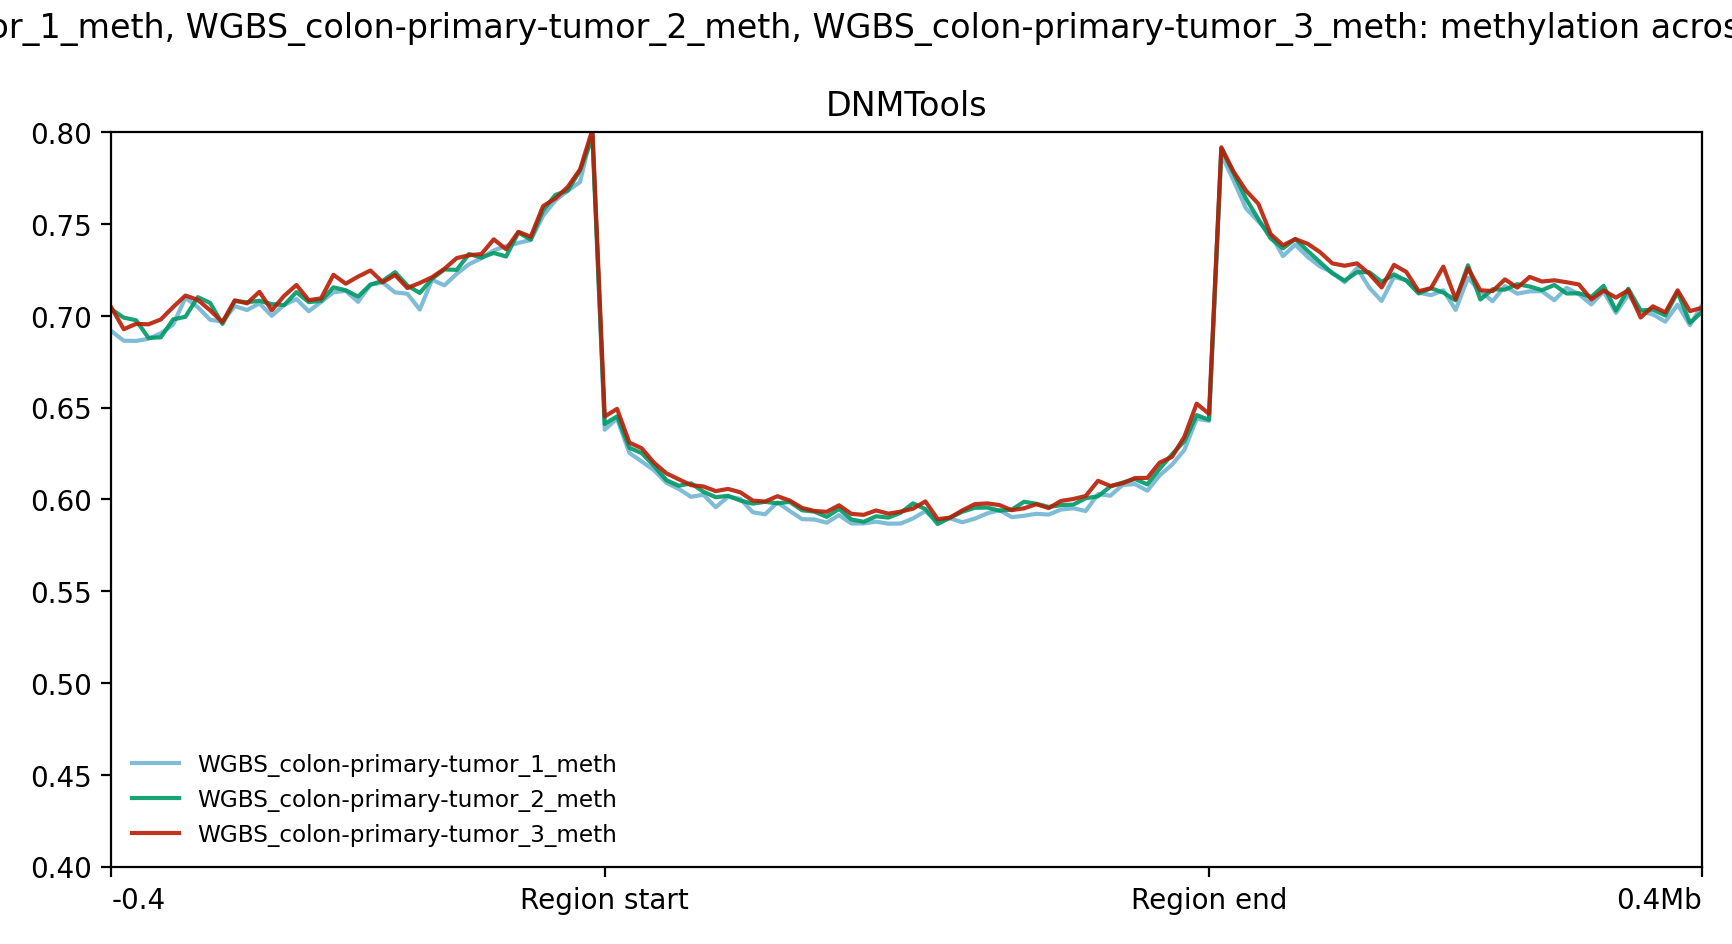

### WGBS_colon-primary-tumor_1_meth, WGBS_colon-primary-tumor_2_meth, WGBS_colon-primary-tumor_3_meth - DNMTools Array

Samples: `WGBS_colon-primary-tumor_1_meth`, `WGBS_colon-primary-tumor_2_meth`, `WGBS_colon-primary-tumor_3_meth`

Matrix: `/uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/out/methylation_deeptools/deeptools/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth/dnmtools_array/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth.dnmtools_array.methylation.matrix.gz`

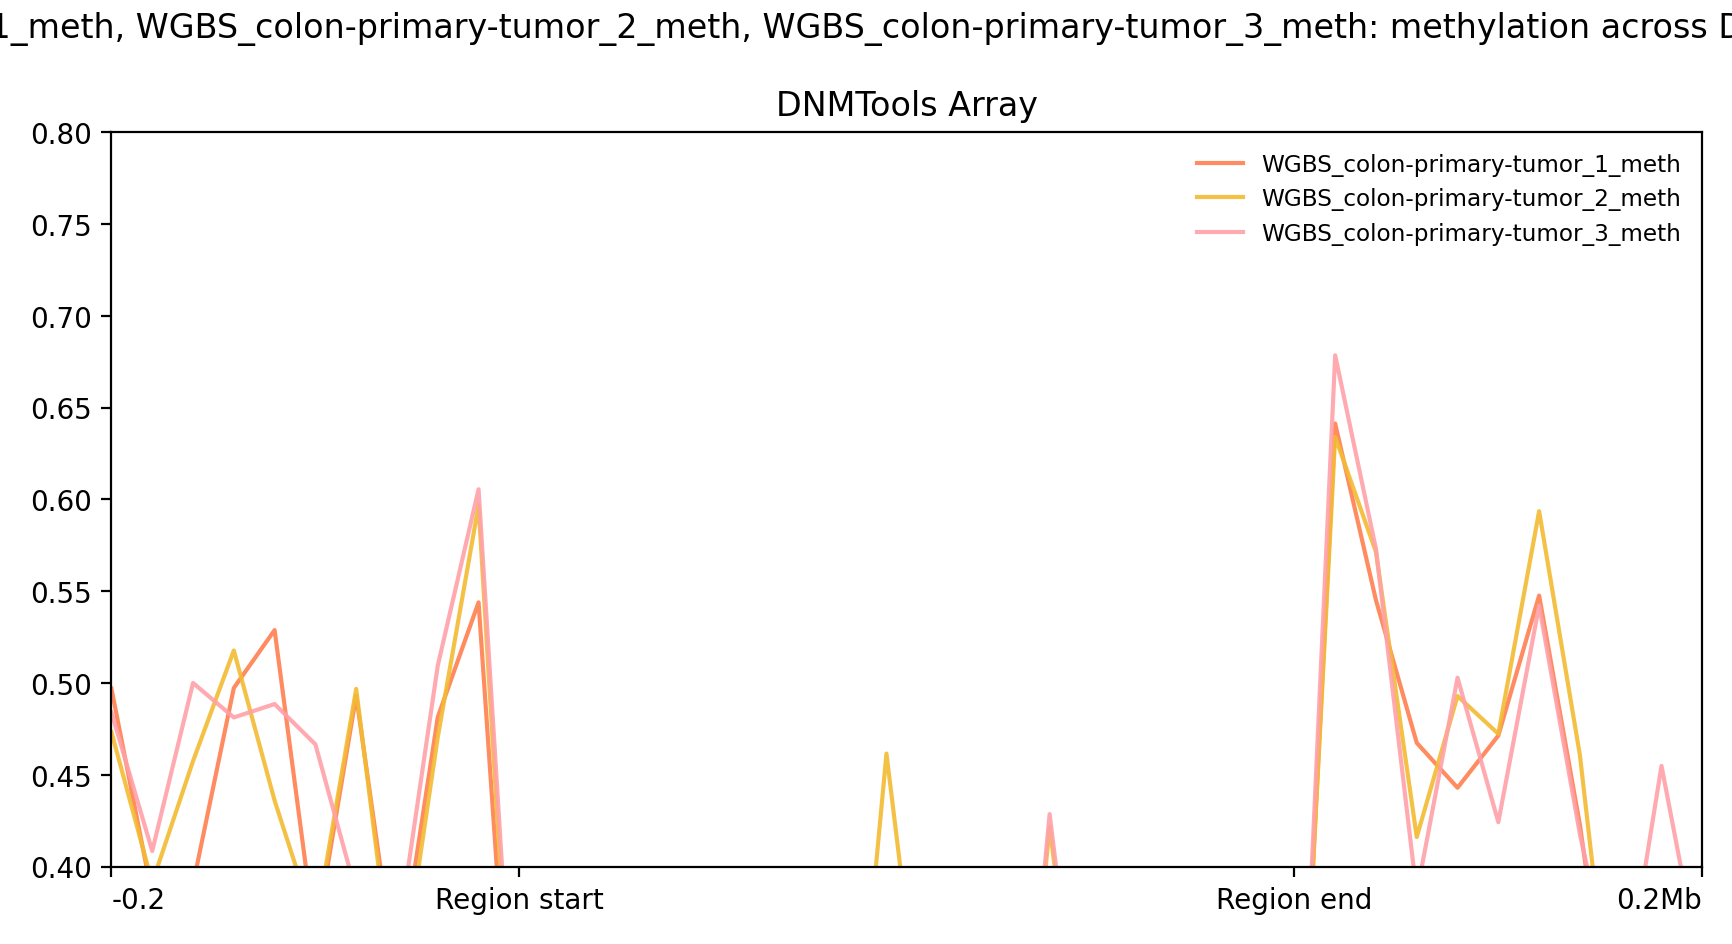

### WGBS_colon-primary-tumor_1_meth, WGBS_colon-primary-tumor_2_meth, WGBS_colon-primary-tumor_3_meth - DNMTools PMR

Samples: `WGBS_colon-primary-tumor_1_meth`, `WGBS_colon-primary-tumor_2_meth`, `WGBS_colon-primary-tumor_3_meth`

Matrix: `/uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/out/methylation_deeptools/deeptools/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth/dnmtools_pmr/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth.dnmtools_pmr.methylation.matrix.gz`

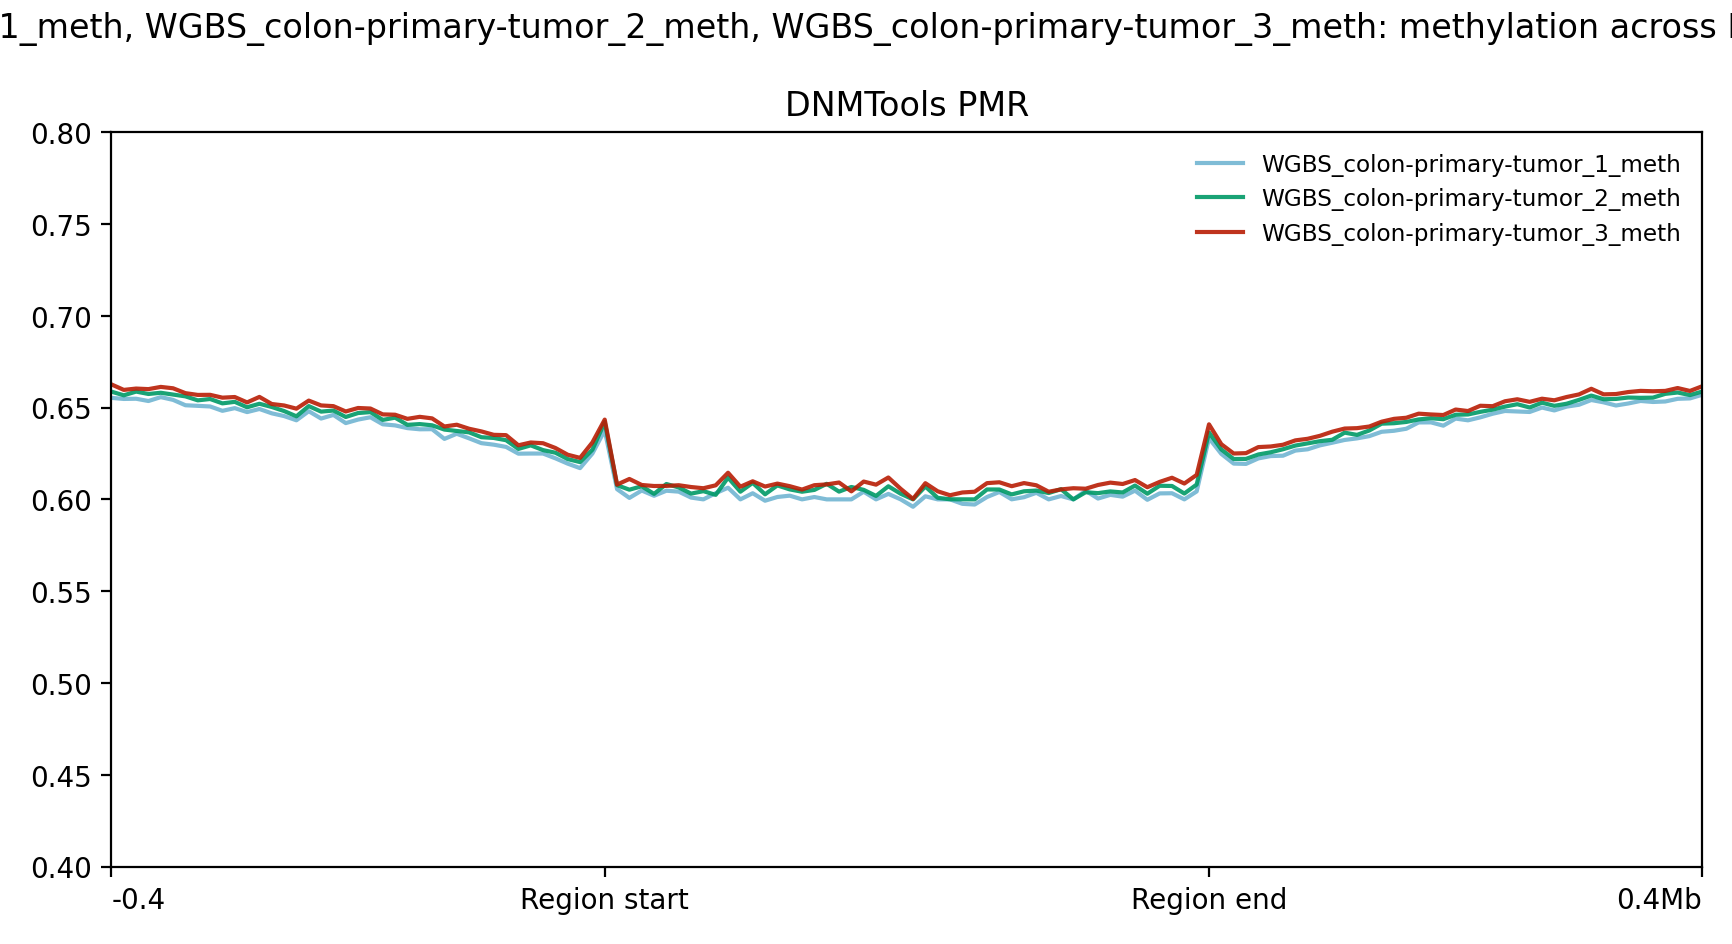

### WGBS_colon-primary-tumor_1_meth, WGBS_colon-primary-tumor_2_meth, WGBS_colon-primary-tumor_3_meth - MethylLasso

Samples: `WGBS_colon-primary-tumor_1_meth`, `WGBS_colon-primary-tumor_2_meth`, `WGBS_colon-primary-tumor_3_meth`

Matrix: `/uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/out/methylation_deeptools/deeptools/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth/methylasso/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth.methylasso.methylation.matrix.gz`

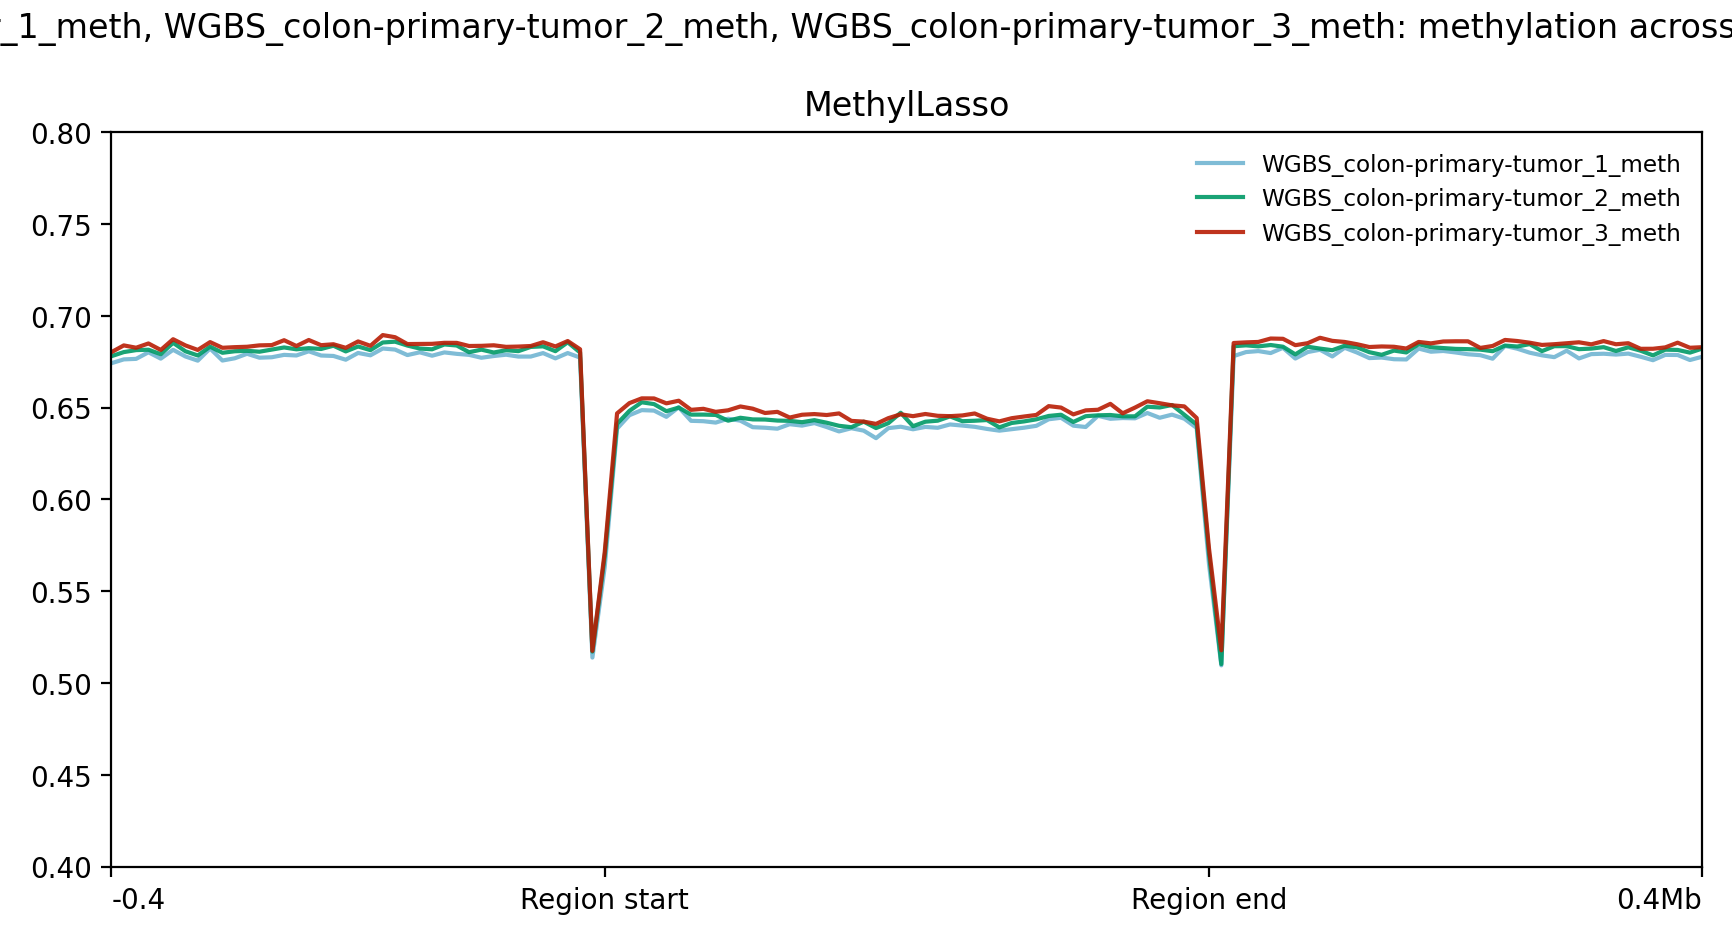

### WGBS_colon-primary-tumor_1_meth, WGBS_colon-primary-tumor_2_meth, WGBS_colon-primary-tumor_3_meth - MethylSeekR

Samples: `WGBS_colon-primary-tumor_1_meth`, `WGBS_colon-primary-tumor_2_meth`, `WGBS_colon-primary-tumor_3_meth`

Matrix: `/uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/out/methylation_deeptools/deeptools/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth/methylseekr/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth.methylseekr.methylation.matrix.gz`

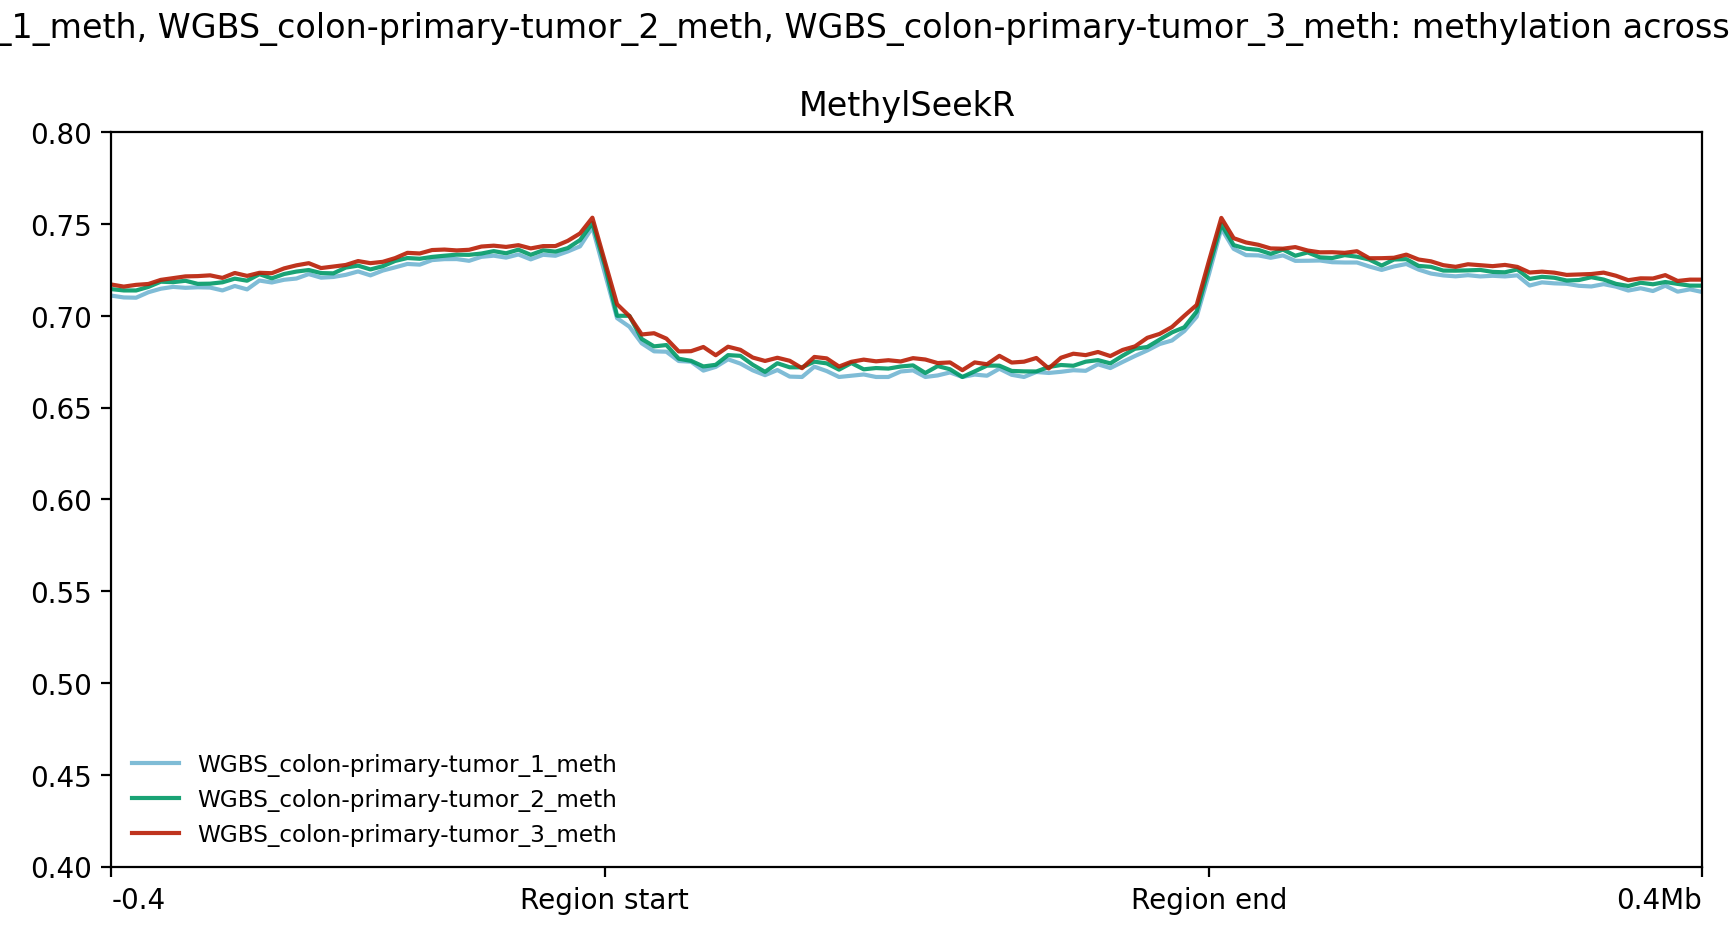

### WGBS_colon-primary-tumor_1_meth, WGBS_colon-primary-tumor_2_meth, WGBS_colon-primary-tumor_3_meth - MethylSeg HM450K

Samples: `WGBS_colon-primary-tumor_1_meth`, `WGBS_colon-primary-tumor_2_meth`, `WGBS_colon-primary-tumor_3_meth`

Matrix: `/uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/out/methylation_deeptools/deeptools/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth/methylseg_hm450k/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth.methylseg_hm450k.methylation.matrix.gz`

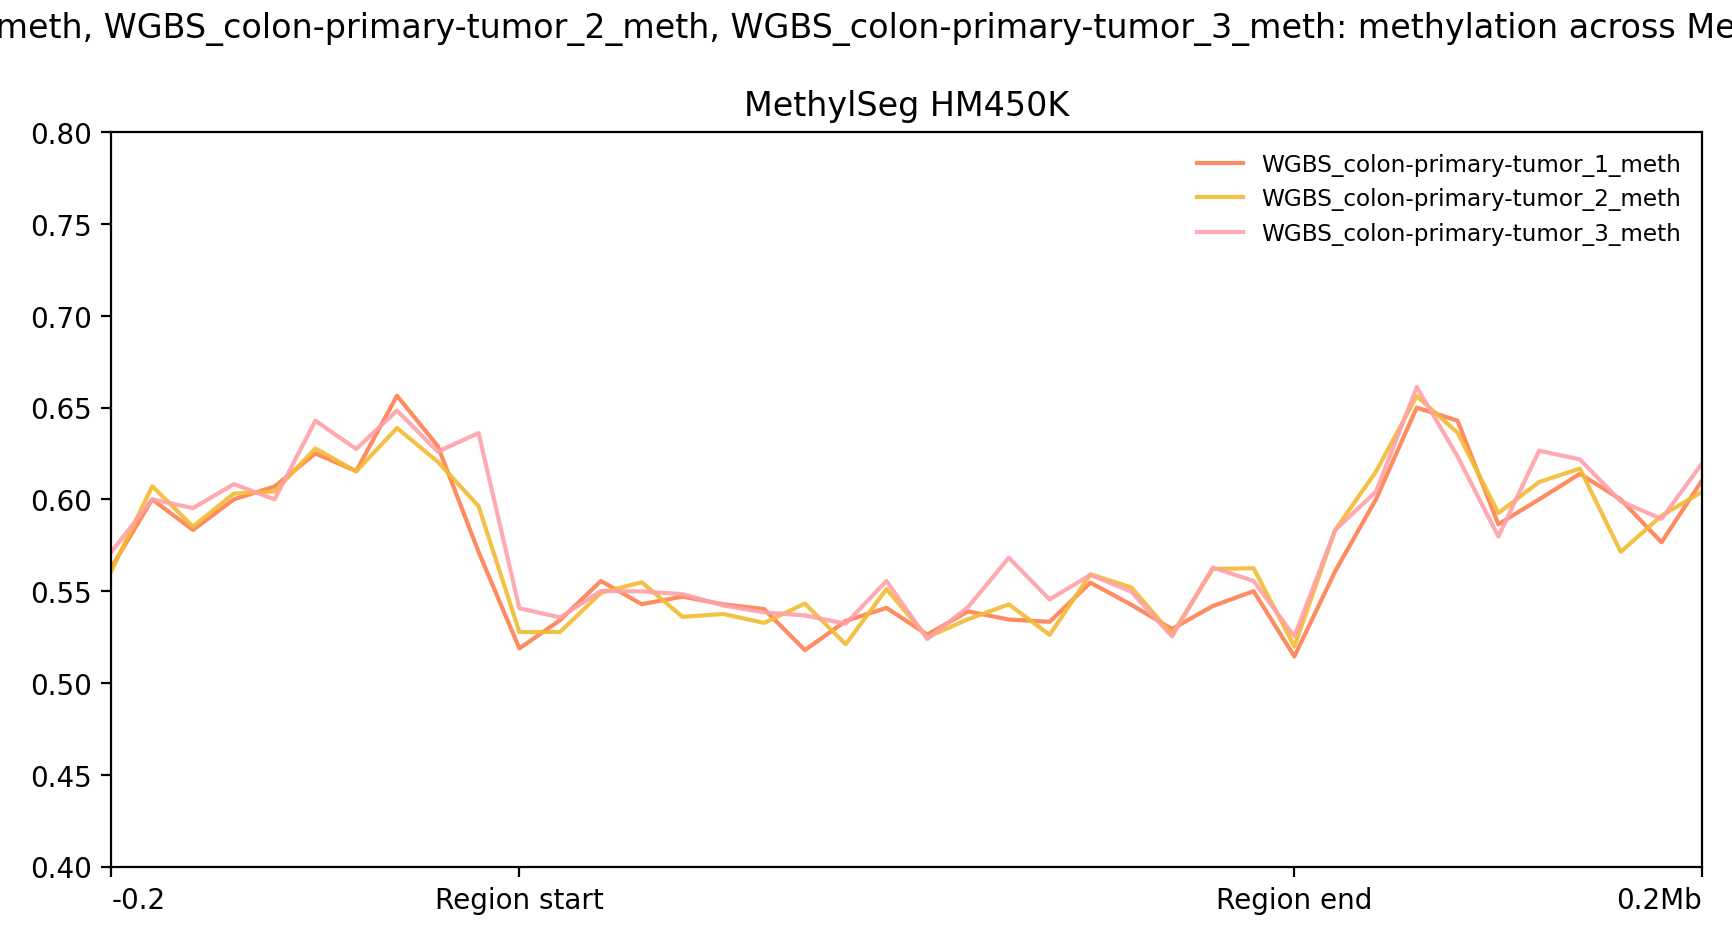

### WGBS_colon-primary-tumor_1_meth, WGBS_colon-primary-tumor_2_meth, WGBS_colon-primary-tumor_3_meth - MethylSeg WGBS

Samples: `WGBS_colon-primary-tumor_1_meth`, `WGBS_colon-primary-tumor_2_meth`, `WGBS_colon-primary-tumor_3_meth`

Matrix: `/uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/out/methylation_deeptools/deeptools/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth/methylseg_wgbs/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth.methylseg_wgbs.methylation.matrix.gz`

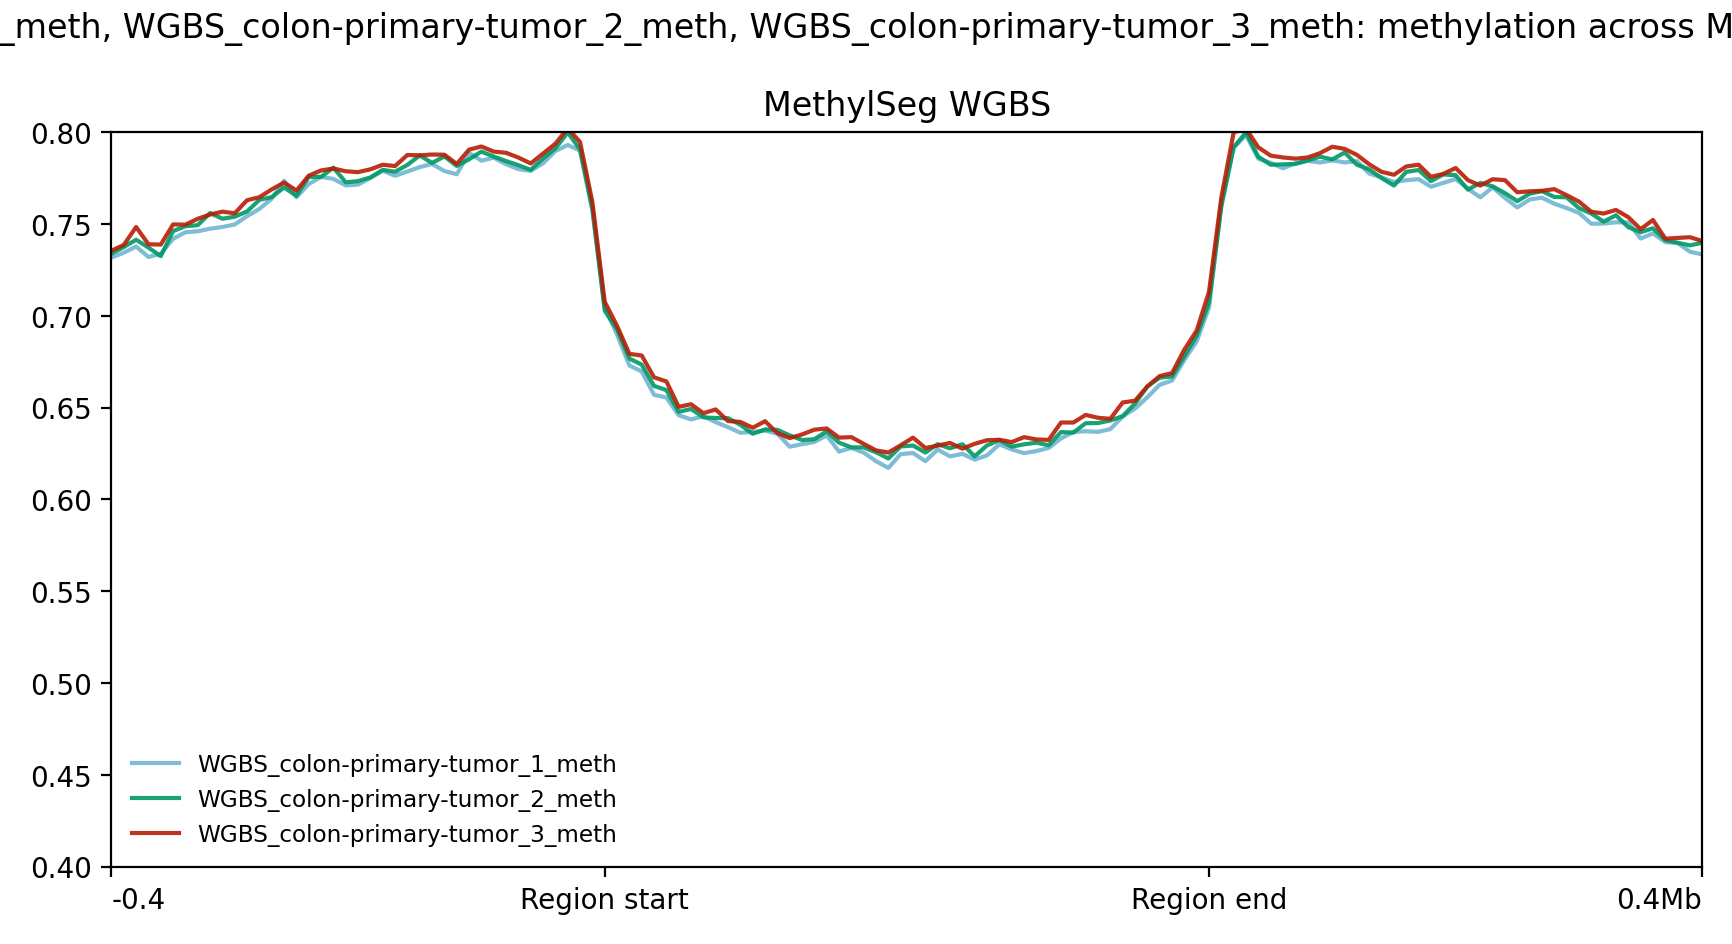

### WGBS_colon-primary-tumor_1_meth, WGBS_colon-primary-tumor_2_meth, WGBS_colon-primary-tumor_3_meth - MMSeekR

Samples: `WGBS_colon-primary-tumor_1_meth`, `WGBS_colon-primary-tumor_2_meth`, `WGBS_colon-primary-tumor_3_meth`

Matrix: `/uufs/chpc.utah.edu/common/home/clementm-group1/projects/20260624_methylseg/analysis/01_region_calling_analysis/out/methylation_deeptools/deeptools/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth/mmseekr/WGBS_colon-primary-tumor_1_meth__WGBS_colon-primary-tumor_2_meth__WGBS_colon-primary-tumor_3_meth.mmseekr.methylation.matrix.gz`

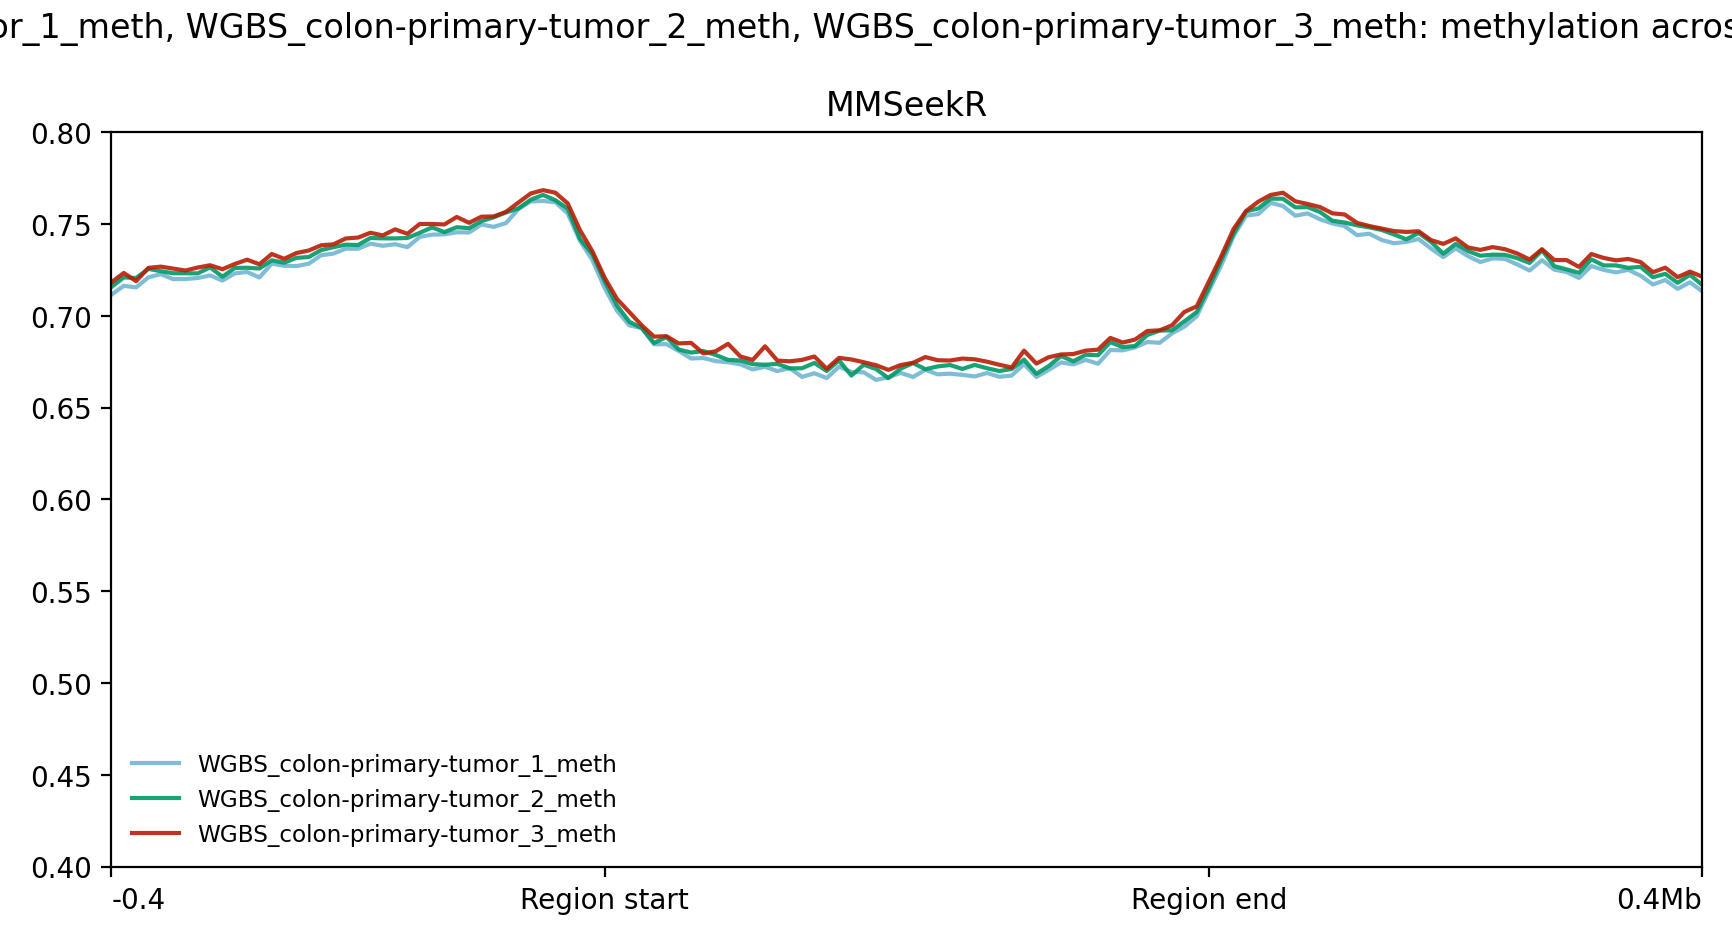

In [11]:
if 'profile_plot_outputs_df' not in globals() or profile_plot_outputs_df.empty:
    display(Markdown("### Preview\nNo cached profile plots are available to preview yet."))
else:
    preview_df = profile_plot_outputs_df.copy()
    if DISPLAY_SAMPLES is not None:
        preview_df = preview_df.loc[
            preview_df.apply(
                lambda row: row_matches_display_samples(row, DISPLAY_SAMPLES),
                axis=1,
            )
        ].copy()
    preview_df = preview_df.sort_values(["sample_label", "tool"]).reset_index(drop=True)
    for row in preview_df.itertuples(index=False):
        display(Markdown(f"### {row.sample_label} - {row.tool_label}"))
        if int(getattr(row, "n_samples", 1)) > 1:
            display(Markdown(f"Samples: `{str(row.member_sample_ids).replace('|', '`, `')}`"))
        display(Markdown(f"Matrix: `{row.matrix_path}`"))
        if Path(row.profile_path).exists():
            display(Image(filename=row.profile_path))
        else:
            display(Markdown(f"Missing profile image: `{row.profile_path}`"))
